# Tarea Viernes - Vuelos España

In [95]:
#Librerías
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

In [13]:
vuelos = pd.read_excel("VUELOS.xlsx")
vuelos.head()

,MES,Vuelos
0,1995M01,53180
1,1995M02,48647
2,1995M03,55353
3,1995M04,56751
4,1995M05,59487


In [14]:
vuelos['MES'] = pd.to_datetime(vuelos['MES'], format='%YM%m')
vuelos.index = vuelos['MES']
del vuelos['MES']
print(vuelos.head())

            Vuelos
MES               
1995-01-01   53180
1995-02-01   48647
1995-03-01   55353
1995-04-01   56751
1995-05-01   59487


Text(0.5, 1.0, 'Vuelos regulares en España')

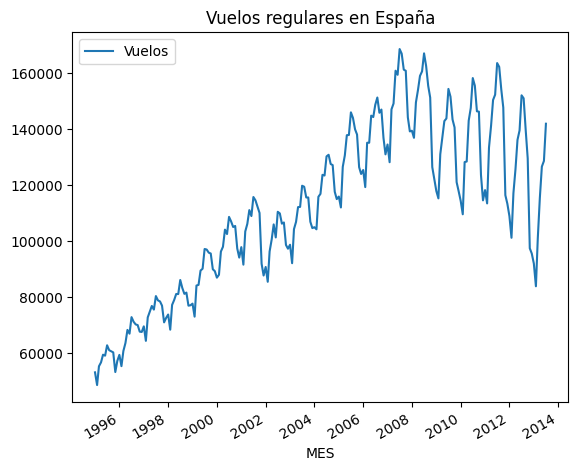

In [15]:
sns.lineplot(vuelos)
plt.xticks(rotation=30, ha='right')
# Ajustes de diseño
plt.title('Vuelos regulares en España')

No es estacionaria, ya que ni la media ni la varianza son constantes
Tiene una clara tendencia creciente hasta el 2008 y luego una caída desde ese año, debido posiblemente a la crisis -tambien aumenta la varianza  a partir de este punto
La variabilidad cambia a lo largo del tiempo, es heterocedastica
Tiene fuerte comportamiento estacional
El periodo es 12, es un ciclo anual 

# Estacionalidad

In [37]:
result = seasonal_decompose(vuelos, model='multiplicative', period = 12)

# Componentes
estacional = result.seasonal
irregular = result.resid

In [38]:
# Coeficientes estacionales por mes
coef_est = estacional.groupby(estacional.index.month).mean()

coef_est.index = [
    'Ene','Feb','Mar','Abr','May','Jun',
    'Jul','Ago','Sep','Oct','Nov','Dic'
]

print(coef_est)

Ene    0.906183
Feb    0.866777
Mar    0.976114
Abr    0.999328
May    1.054177
Jun    1.049321
Jul    1.114847
Ago    1.098805
Sep    1.060600
Oct    1.044421
Nov    0.924759
Dic    0.904668
Name: seasonal, dtype: float64


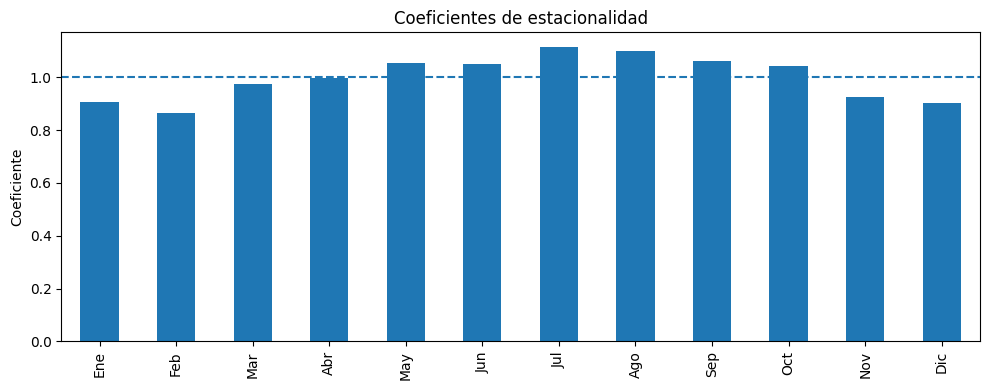

In [52]:
# Gráfico conjunto

plt.figure(figsize=(10, 4))

coef_est.plot(kind='bar')
plt.axhline(1, linestyle='--')

plt.title('Coeficientes de estacionalidad')
plt.ylabel('Coeficiente')

plt.tight_layout()
plt.show()


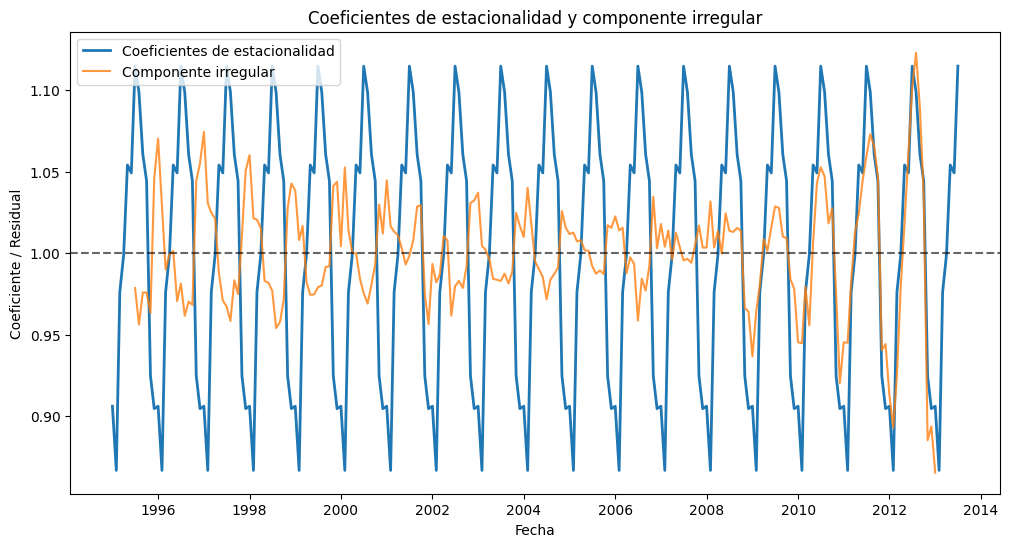

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(estacional, label='Coeficientes de estacionalidad', linewidth=2)
plt.plot(irregular, label='Componente irregular', linewidth=1.5, alpha=0.8)

plt.axhline(1, linestyle='--', color='black', alpha=0.6)
plt.title('Coeficientes de estacionalidad y componente irregular')
plt.xlabel('Fecha')
plt.ylabel('Coeficiente / Residual')
plt.legend()
plt.show()

El mes con mayor coeficiente es julio. Esto sigifica que es el mes de máxima actividad (11% más respecto al nivel medio)
El que menor tiene es Febrero, que significa que es el mes de mínima actividad (13% menos respecto del nivel medio)

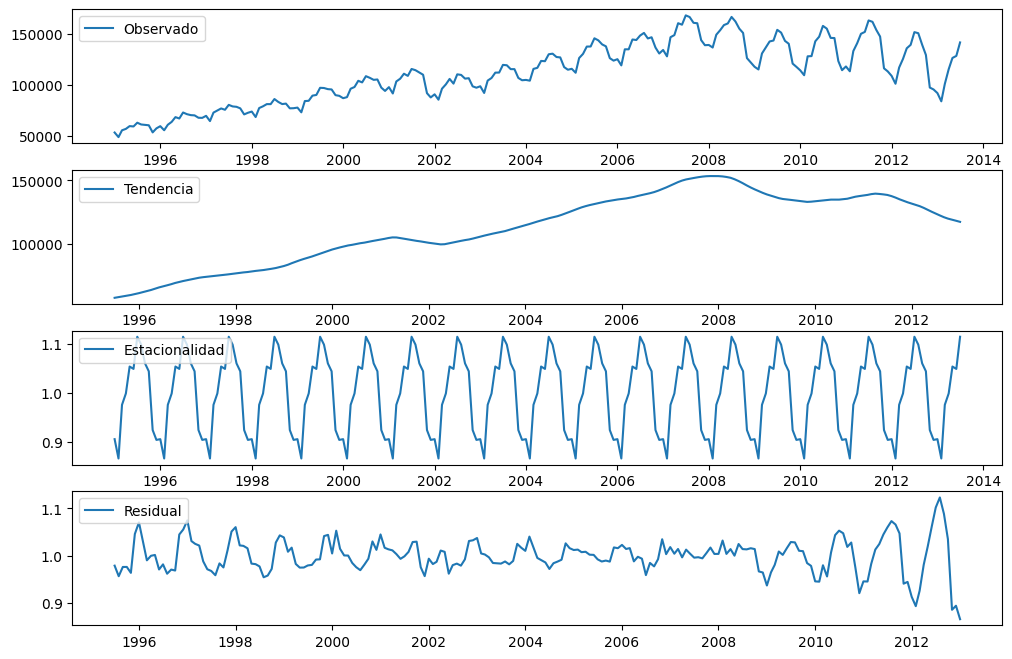

In [ ]:
# Realizar la descomposición estacional


# Visualizar las componentes
plt.figure(figsize=(12, 8))
plt.subplot(4, 1, 1)
plt.plot(result.observed, label='Observado')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(result.seasonal,
label='Estacionalidad')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(result.resid,
label='Residual')
plt.legend(loc='upper left')
plt.show()

La tendencia en los ultimos 4 años es claramente descendente, con un ligero repunte en el 2011
El comportamiento estacional de toda la serie es muy regular

# Representacion de las 3 series

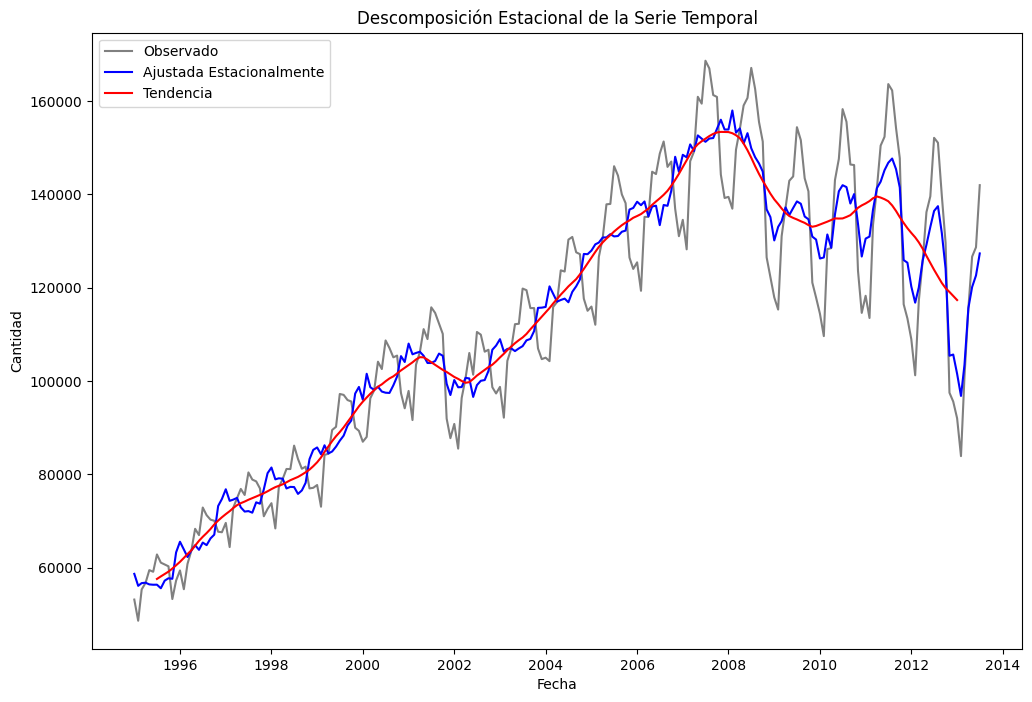

In [40]:
# Crear un gráfico que muestre las componentes
plt.figure(figsize=(12, 8))
plt.plot(result.observed, label='Observado', color='grey')
plt.plot(result.observed/result.seasonal, label='Ajustada Estacionalmente', color='blue')
plt.plot(result.trend, label='Tendencia', color='red')
# Añadir leyendas y título
plt.legend()
plt.title('Descomposición Estacional de la Serie Temporal')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
# Mostrar el gráfico
plt.show()

La serie ajustada estacionalmente es la serie original sin el efecto estacional

serie_ajustada = observada / estacionalidad

# Series de cada año

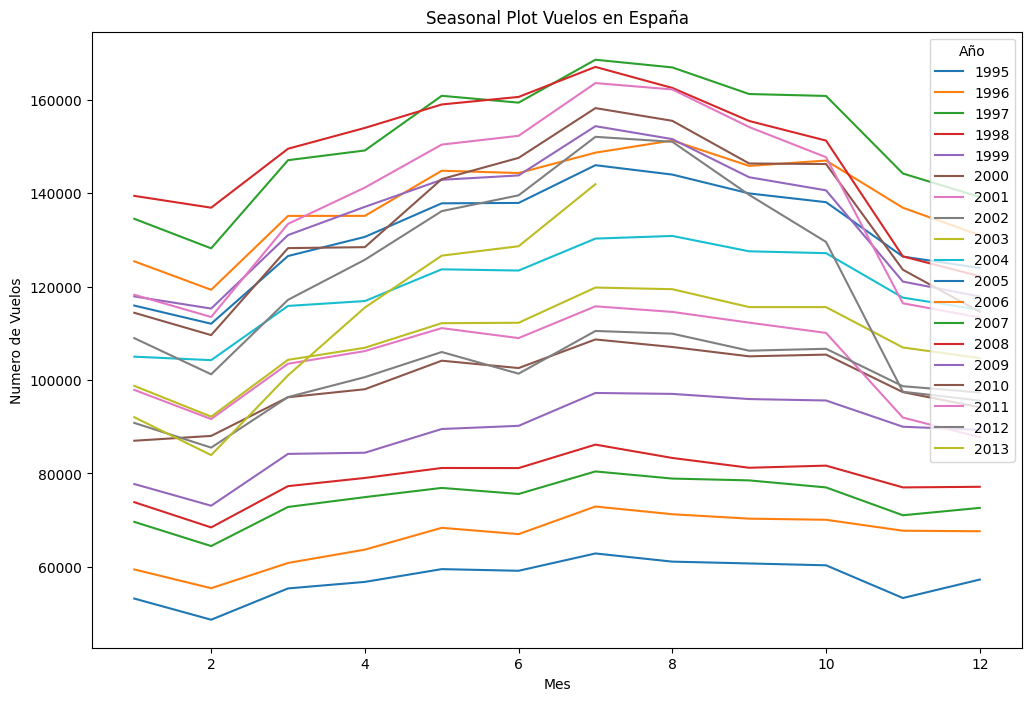

In [42]:
#Para estudiar el comportamiento estacional puede resultar útil la representación gráfica de los valores de la serie, dibujando cada año en un color diferente.
vuelos['Año'] = pd.to_datetime(vuelos.index, format='%YM%m').year
plt.figure(figsize=(12, 8))
for Año, datos_año in vuelos.groupby('Año'):
 plt.plot(datos_año.index.month, datos_año['Vuelos'], label=str(Año))
# Añadir leyendas y título
plt.legend(title='Año')
plt.title('Seasonal Plot Vuelos en España')
plt.xlabel('Mes')
plt.ylabel('Numero de Vuelos')
# Mostrar el gráfico
plt.show()

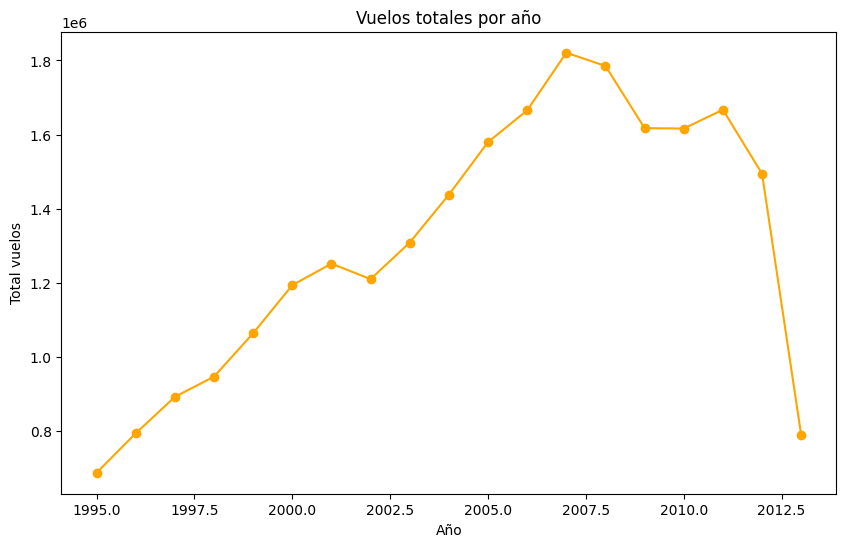

In [71]:
vuelos_anuales = vuelos['Vuelos'].resample('YE').sum()

años = vuelos_anuales.index.year
valores = vuelos_anuales.values

plt.figure(figsize=(10,6))

plt.plot(años, valores, color='orange')
plt.scatter(años, valores, color='orange')

plt.title('Vuelos totales por año')
plt.xlabel('Año')
plt.ylabel('Total vuelos')

plt.show()

plt.show()

Hubo más vuelos en el año 2007

# Split de datos

In [46]:
# Serie original
serie = vuelos['Vuelos']

# Split temporal
train = serie.iloc[:-12]   # todo menos último año
test = serie.iloc[-12:]    # último año

print(len(train), len(test))

211 12


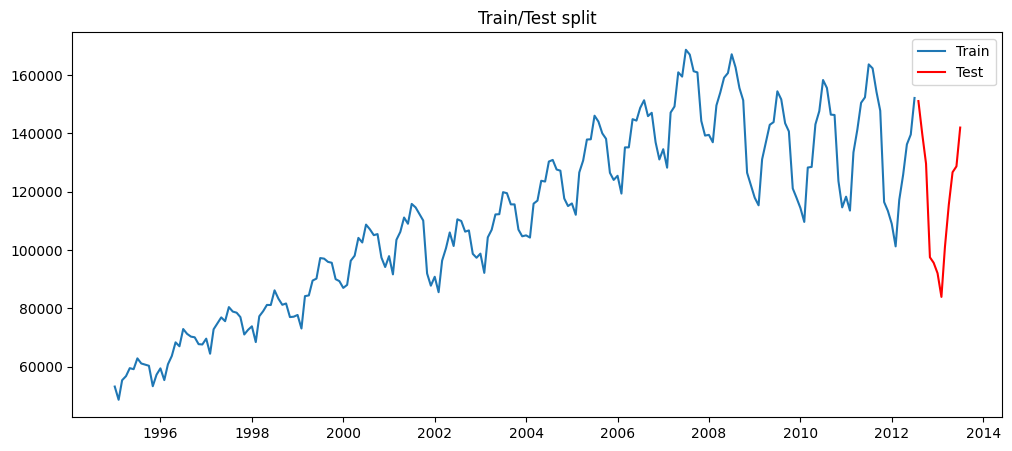

In [48]:
plt.figure(figsize=(12,5))

plt.plot(train, label='Train')
plt.plot(test, label='Test', color='red')

plt.legend()
plt.title('Train/Test split')
plt.show()

# Modelado

### Modelo 1 - aditivo y multiplicativo

In [54]:
modelo_hw = sm.tsa.ExponentialSmoothing(
    train,
    trend='add',
    seasonal='multiplicative',
    seasonal_periods=12
).fit()

c:\MASTER\MINERIA - SERIES TEMPORALES\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [55]:
pred_hw = modelo_hw.forecast(steps=12)

In [56]:
modelo_hw.summary()

Dep. Variable:,Vuelos,No. Observations:,211
Model:,ExponentialSmoothing,SSE,1498558165.458
Optimized:,True,AIC,3360.717
Trend:,Additive,BIC,3414.347
Seasonal:,Multiplicative,AICC,3364.280
Seasonal Periods:,12,Date:,"Sat, 09 May 2026"
Box-Cox:,False,Time:,09:52:53
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.0055605,beta,True


In [ ]:
suavizada_hw = modelo_hw.fittedvalues

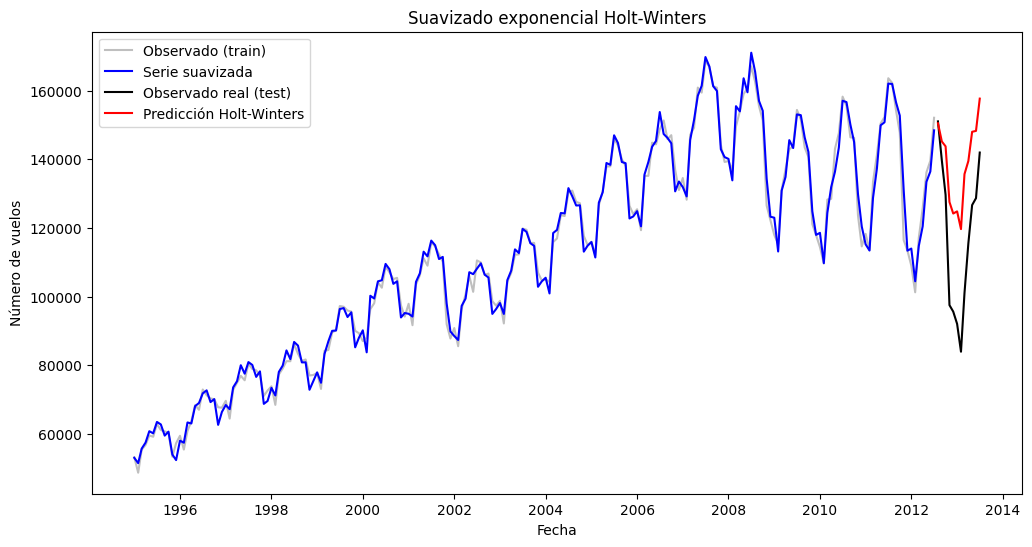

In [ ]:
suavizada_hw = modelo_hw.fittedvalues

plt.figure(figsize=(12, 6))

plt.plot(train, label='Observado (train)', color='grey', alpha=0.5)
plt.plot(suavizada_hw, label='Serie suavizada', color='blue')
plt.plot(test, label='Observado real (test)', color='black')
plt.plot(pred_hw, label='Predicción Holt-Winters', color='red')

plt.title('Suavizado exponencial Holt-Winters')
plt.xlabel('Fecha')
plt.ylabel('Número de vuelos')
plt.legend()
plt.show()

In [59]:
# Tabla de predicciones
tabla_pred_hw = pd.DataFrame({
    'Real': test,
    'Predicción': pred_hw
})

tabla_pred_hw

,Real,Predicción
2012-08-01,151057,150505.462775
2012-09-01,139680,145202.727127
2012-10-01,129597,143767.639075
2012-11-01,97494,127553.877773
2012-12-01,95608,124191.858906
2013-01-01,92031,124823.183895
2013-02-01,83918,119657.786216
2013-03-01,101013,135687.857804
2013-04-01,115542,139513.397224
2013-05-01,126659,148017.180690


### Prueba de varios modelos

In [ ]:
modelos = {
    'add-add': ('add', 'add'),
    'mul-mul': ('mul', 'mul'),
    'add-mul': ('add', 'mul')
}

resultados = {}

for nombre, (t, s) in modelos.items():
    modelo = sm.tsa.ExponentialSmoothing(
        train,
        trend=t,
        seasonal=s,
        seasonal_periods=12
    ).fit()

    pred = modelo.forecast(12)

    rmse = np.sqrt(mean_squared_error(test, pred))

    resultados[nombre] = {
        'AIC': modelo.aic,
        'RMSE': rmse
    }

pd.DataFrame(resultados).T

c:\MASTER\MINERIA - SERIES TEMPORALES\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MASTER\MINERIA - SERIES TEMPORALES\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MASTER\MINERIA - SERIES TEMPORALES\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,AIC,RMSE
add-add,3451.988474,13879.404472
mul-mul,3359.539689,23852.236113
add-mul,3360.717248,24443.320158


### Modelo 2 - aditivo - aditivo

In [133]:
modelo_hw2 = sm.tsa.ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

c:\MASTER\MINERIA - SERIES TEMPORALES\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [134]:
pred_hw = modelo_hw2.forecast(steps=12)

In [135]:
modelo_hw2.summary()

Dep. Variable:,Vuelos,No. Observations:,211
Model:,ExponentialSmoothing,SSE,2309586430.911
Optimized:,True,AIC,3451.988
Trend:,Additive,BIC,3505.618
Seasonal:,Additive,AICC,3455.551
Seasonal Periods:,12,Date:,"Sat, 09 May 2026"
Box-Cox:,False,Time:,11:23:11
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.5284209,alpha,True
smoothing_trend,0.000000,beta,True


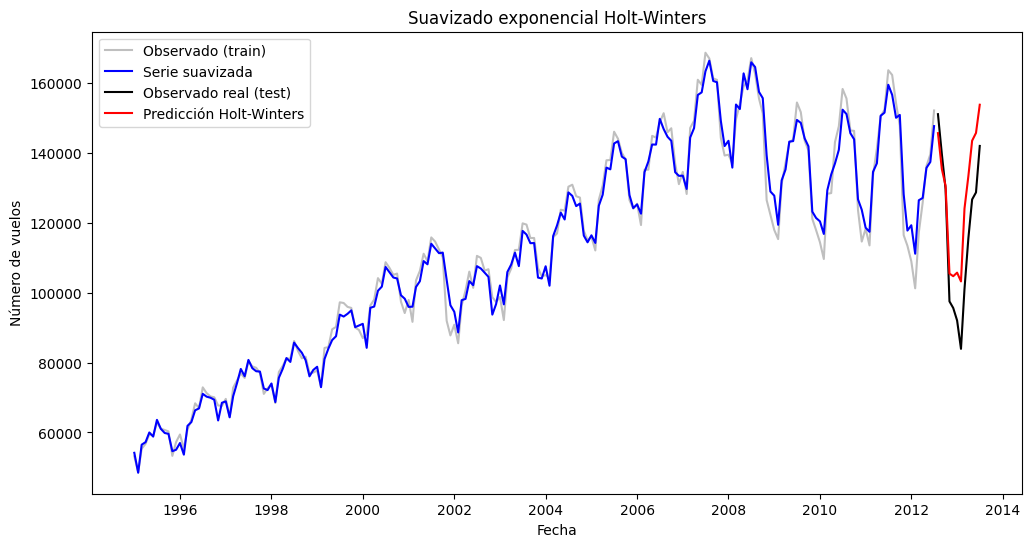

In [136]:
suavizada_hw2 = modelo_hw2.fittedvalues

plt.figure(figsize=(12, 6))

plt.plot(train, label='Observado (train)', color='grey', alpha=0.5)
plt.plot(suavizada_hw2, label='Serie suavizada', color='blue')
plt.plot(test, label='Observado real (test)', color='black')
plt.plot(pred_hw, label='Predicción Holt-Winters', color='red')

plt.title('Suavizado exponencial Holt-Winters')
plt.xlabel('Fecha')
plt.ylabel('Número de vuelos')
plt.legend()
plt.show()

In [137]:
rmse_final = np.sqrt(
    mean_squared_error(test, pred_hw)
)

print(f'RMSE final: {rmse_final:.2f}')

RMSE final: 13879.40


Vemos que este modelo es mucho mejor

# Diferenciamos serie y eliminamos heterocedasticdad

In [83]:
vuelos_log = np.log(vuelos['Vuelos'])

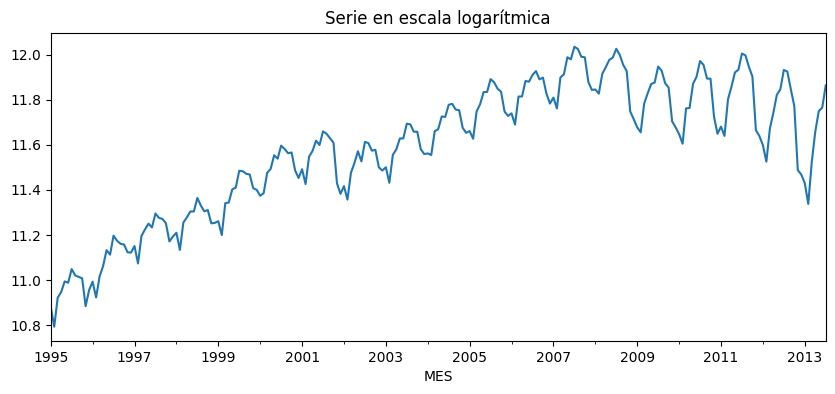

In [84]:
vuelos_log.plot(figsize=(10,4))
plt.title('Serie en escala logarítmica')
plt.show()

In [86]:
vuelos_2 = vuelos_log.diff()

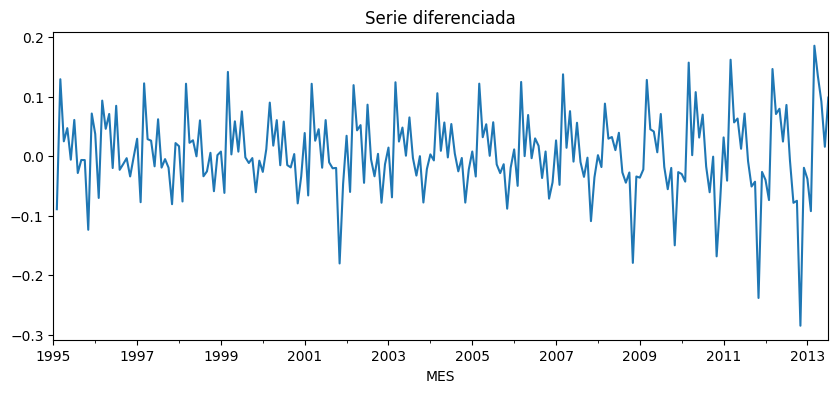

In [87]:
vuelos_2.plot(figsize=(10,4))
plt.title('Serie diferenciada')
plt.show()

In [113]:
#Eliminamos valor nulo
vuelos_2 = vuelos_2.dropna()

### Split

In [114]:
# Serie original
serie2 = vuelos_2

# Split temporal
train2 = serie2.iloc[:-12]   # todo menos último año
test2 = serie2.iloc[-12:]    # último año

print(len(train2), len(test2))

210 12


### Modelo

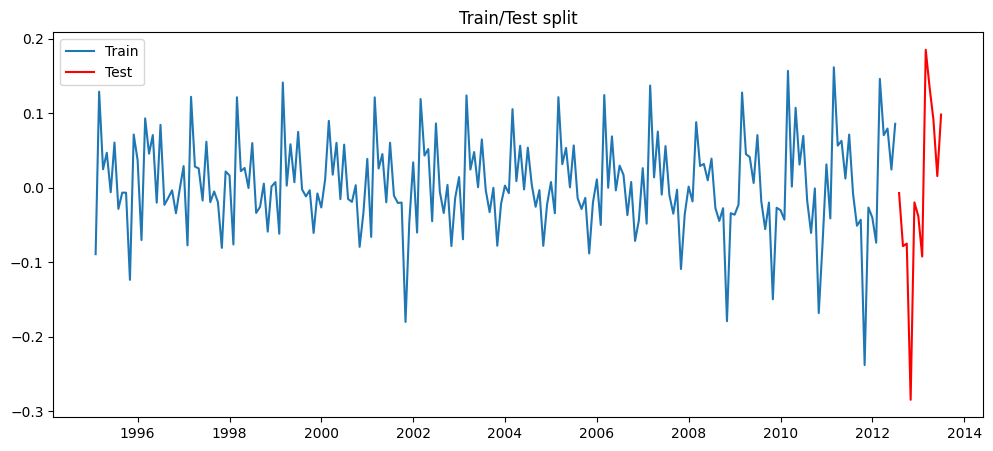

In [115]:
plt.figure(figsize=(12,5))

plt.plot(train2, label='Train')
plt.plot(test2, label='Test', color='red')

plt.legend()
plt.title('Train/Test split')
plt.show()

### Modelado

In [117]:
modelo_hw3 = sm.tsa.ExponentialSmoothing(
    train2,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

c:\MASTER\MINERIA - SERIES TEMPORALES\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [125]:
pred_hw3 = modelo_hw3.forecast(steps=12)

In [120]:
modelo_hw3.summary()

Dep. Variable:,Vuelos,No. Observations:,210
Model:,ExponentialSmoothing,SSE,0.115
Optimized:,True,AIC,-1545.649
Trend:,Additive,BIC,-1492.096
Seasonal:,Additive,AICC,-1542.068
Seasonal Periods:,12,Date:,"Sat, 09 May 2026"
Box-Cox:,False,Time:,11:07:58
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.4901e-08,alpha,True
smoothing_trend,1.4896e-08,beta,True


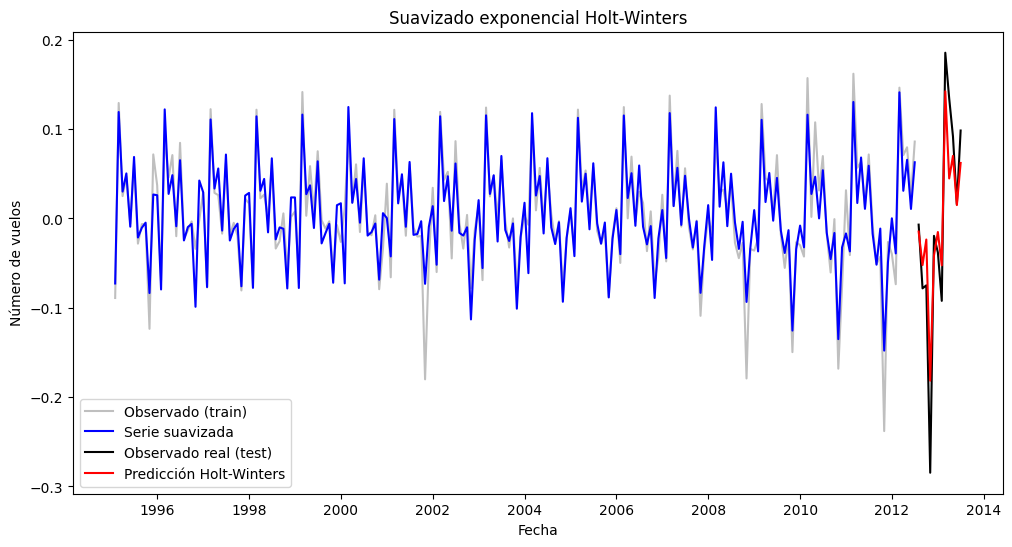

In [126]:
suavizada_hw3 = modelo_hw3.fittedvalues

plt.figure(figsize=(12, 6))

plt.plot(train2, label='Observado (train)', color='grey', alpha=0.5)
plt.plot(suavizada_hw3, label='Serie suavizada', color='blue')
plt.plot(test2, label='Observado real (test)', color='black')
plt.plot(pred_hw3, label='Predicción Holt-Winters', color='red')

plt.title('Suavizado exponencial Holt-Winters')
plt.xlabel('Fecha')
plt.ylabel('Número de vuelos')
plt.legend()
plt.show()

### Volver a escala original

In [127]:
# Último valor log real antes del periodo test
serie_original = vuelos['Vuelos']
serie_log = np.log(serie_original)

ultimo_log = serie_log.loc[train2.index[-1]]

# Desdiferenciar: acumulamos las predicciones
pred_log_reconstruida = ultimo_log + pred_hw3.cumsum()

# Deshacer logaritmo
pred_original = np.exp(pred_log_reconstruida)

# Test en escala original
test_original = serie_original.loc[pred_original.index]

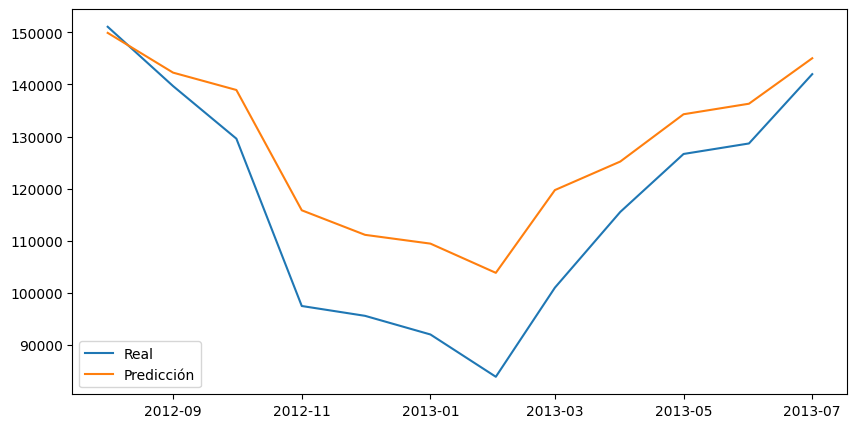

In [123]:
test_original = vuelos['Vuelos'].iloc[-12:]

plt.figure(figsize=(10,5))

plt.plot(test_original, label='Real')
plt.plot(pred_original, label='Predicción')

plt.legend()
plt.show()

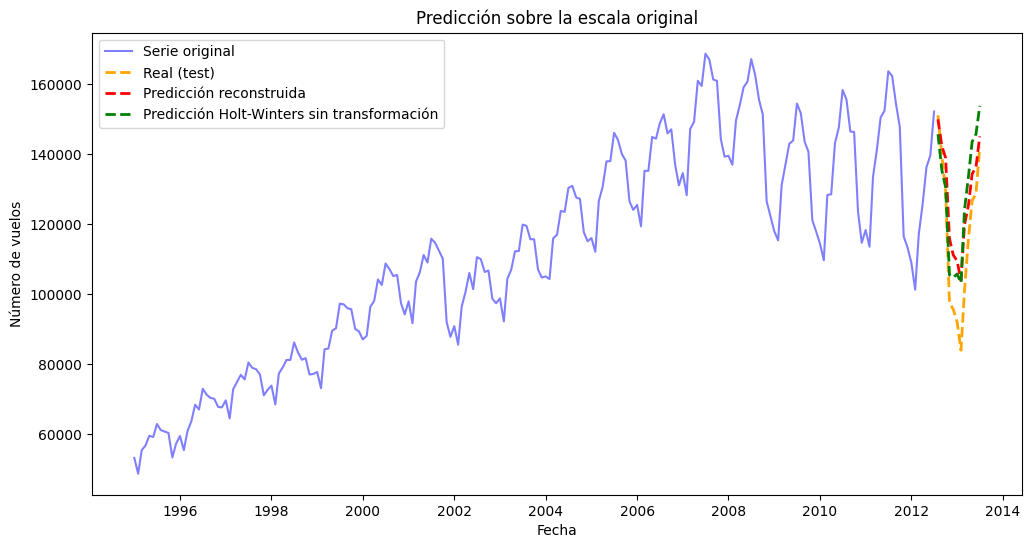

In [142]:
plt.figure(figsize=(12,6))

plt.plot(train, 
         label='Serie original', 
         color='blue', 
         alpha=0.5)

plt.plot(test_original, 
         label='Real (test)', 
         linestyle='--',
         color='orange', 
         linewidth=2)

plt.plot(pred_original, 
         label='Predicción reconstruida',
         linestyle='--',
         color='red', 
         linewidth=2)

plt.plot(pred_hw, 
         label='Predicción Holt-Winters sin transformación',
         linestyle='--',
         color='green', 
         linewidth=2)


plt.title('Predicción sobre la escala original')
plt.xlabel('Fecha')
plt.ylabel('Número de vuelos')
plt.legend()
plt.show()

In [129]:
rmse_final = np.sqrt(
    mean_squared_error(test_original, pred_original)
)

print(f'RMSE final: {rmse_final:.2f}')

RMSE final: 12729.08
